# Statistical Analysis & Non‑LLM Machine Learning Workshop
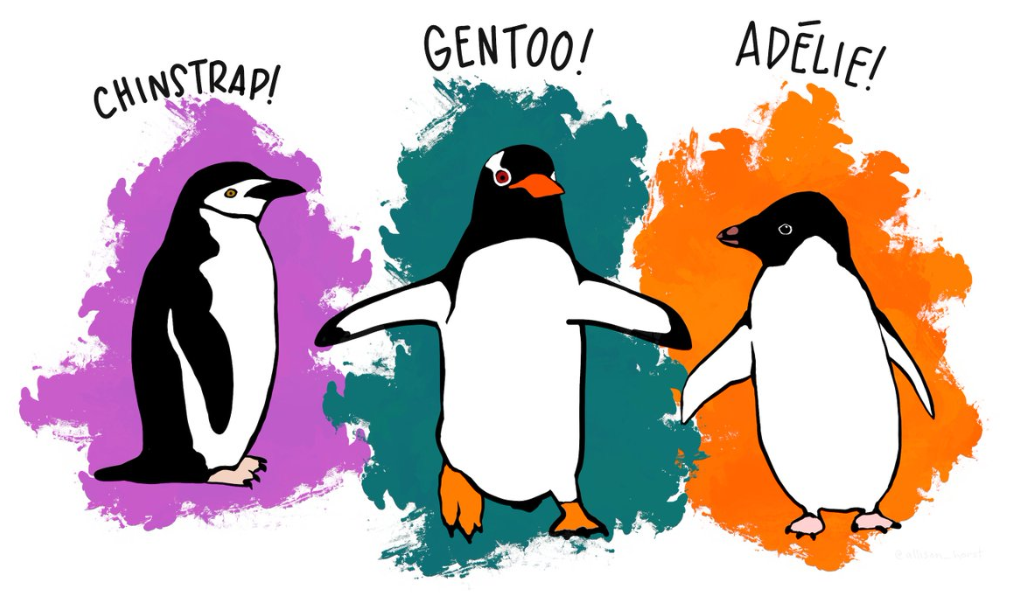

- **Part 1 (Stats Demo):** Sections **1.1–1.6**
- **Part 2 (ML Demo):** Sections **2.1–2.6**

---

## 0. Setup (run once)

Colab usually has these libraries already, but this cell makes the environment consistent.

In [1]:
# Optional: install (quietly). Safe to re-run.
# If you're on Colab, most of these are preinstalled.
#!pip -q install pandas numpy matplotlib scipy statsmodels scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 120


## 0.1 Load the dataset

By default, this notebook expects the Palmer Penguins CSV (<code>Penguindata.csv</code>).

### Option A (recommended): load from a URL
Set `DATA_URL` to your hosted CSV (Netlify or GitHub raw).

### Option B: upload manually
If `DATA_URL` is blank and the file isn't found locally, you'll be prompted to upload.

> Dataset suggested path on Netlify: `/data/Penguindata.csv`

In [3]:
DATA_URL = "./data/Penguindata.csv"  # e.g., "https://YOUR-SITE.netlify.app/Penguindata.csv"

LOCAL_CANDIDATES = ["/content/Penguindata.csv", "/content/data/Penguindata.csv", ]

def load_penguin_data():
    if DATA_URL.strip():
        print(f"Loading from URL: {DATA_URL}")
        return pd.read_csv(DATA_URL)

    for p in LOCAL_CANDIDATES:
        if Path(p).exists():
            print(f"Loading from local path: {p}")
            return pd.read_csv(p)

    # Fallback: Colab upload
    try:
        from google.colab import files  # type: ignore
        print("Dataset not found. Please upload Penguindata.csv now...")
        uploaded = files.upload()
        filename = next(iter(uploaded))
        print(f"Loaded uploaded file: {filename}")
        return pd.read_csv(filename)
    except Exception as e:
        raise FileNotFoundError(
            "Could not find the dataset locally and DATA_URL is empty. "
            "Set DATA_URL to a hosted CSV OR upload the file in Colab."
        ) from e

df = load_penguin_data()

# Small cleanup: strip trailing spaces in column names (this dataset has one like 'Latitude ')
df.columns = df.columns.str.strip()

print("Rows, Columns:", df.shape)
df.head()

Loading from URL: ./data/Penguindata.csv
Rows, Columns: (344, 19)


,studyName,Sample Number,Species,Region,Latitude,Longitude,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,-64.766998,-64.083,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [4]:
# how the big boys and girls load the data

penguin_url = 'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins.csv'
penguin_raw_url = 'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins.csv'

In [5]:
pd.read_csv(penguin_url).to_csv('./data/penguins.csv', index = False)
pd.read_csv(penguin_raw_url).to_csv('./data/penguins_raw.csv', index = False)

### 0.2 Identify key columns (species, body mass, flipper length, culmen)

This dataset has consistent columns, but the names include spaces and units (e.g., <code>Body Mass (g)</code>).
We’ll detect the key columns once and reuse them throughout the demo.

**We will mostly use:**
- <strong>Species</strong> (categorical)
- <strong>Island</strong> (categorical)
- <strong>Body Mass (g)</strong> (numeric)
- <strong>Flipper Length (mm)</strong> (numeric)
- <strong>Culmen Length / Depth</strong> (numeric)

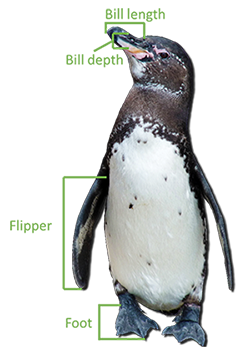
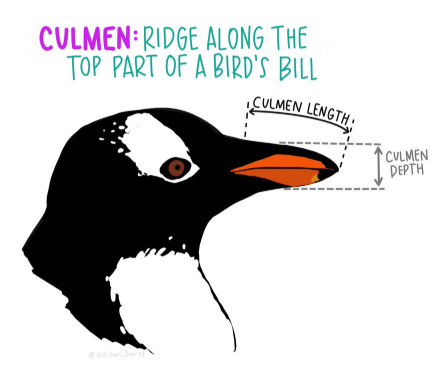

In [6]:
def detect_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

COL_SPECIES = detect_col(df, ["Species", "species"])
COL_ISLAND = detect_col(df, ["Island", "island"])
COL_SEX = detect_col(df, ["Sex", "sex"])

COL_CULMEN_LEN = detect_col(df, ["Culmen Length (mm)", "Bill Length (mm)", "Culmen Length"])
COL_CULMEN_DEPTH = detect_col(df, ["Culmen Depth (mm)", "Bill Depth (mm)", "Culmen Depth"])
COL_FLIPPER = detect_col(df, ["Flipper Length (mm)", "Flipper Length (mm)", "Flipper Length"])
COL_BODY_MASS = detect_col(df, ["Body Mass (g)", "Body Mass", "Body Mass (g)"])

print("Detected columns (may be None):")
print("  COL_SPECIES     =", COL_SPECIES)
print("  COL_ISLAND      =", COL_ISLAND)
print("  COL_SEX         =", COL_SEX)
print("  COL_CULMEN_LEN  =", COL_CULMEN_LEN)
print("  COL_CULMEN_DEPTH=", COL_CULMEN_DEPTH)
print("  COL_FLIPPER     =", COL_FLIPPER)
print("  COL_BODY_MASS   =", COL_BODY_MASS)

assert COL_SPECIES is not None, "Species column not found."

Detected columns (may be None):
  COL_SPECIES     = Species
  COL_ISLAND      = Island
  COL_SEX         = Sex
  COL_CULMEN_LEN  = Culmen Length (mm)
  COL_CULMEN_DEPTH= Culmen Depth (mm)
  COL_FLIPPER     = Flipper Length (mm)
  COL_BODY_MASS   = Body Mass (g)


In [7]:
# Minimal cleaning for analysis
df_demo = df.copy()

# Ensure numeric where expected
for c in [COL_CULMEN_LEN, COL_CULMEN_DEPTH, COL_FLIPPER, COL_BODY_MASS]:
    if c is not None:
        df_demo[c] = pd.to_numeric(df_demo[c], errors="coerce")

# Standardize Sex values a bit (optional; there are some missing values)
if COL_SEX is not None:
    df_demo[COL_SEX] = df_demo[COL_SEX].astype(str).str.strip().str.upper().replace({"NAN": np.nan})

# Create a shorter species label for nicer plots/tables (Adelie / Chinstrap / Gentoo)
df_demo["species_simple"] = df_demo[COL_SPECIES].astype(str).str.split().str[0]

df_demo[["species_simple", COL_ISLAND, COL_SEX, COL_CULMEN_LEN, COL_CULMEN_DEPTH, COL_FLIPPER, COL_BODY_MASS]].head()

,species_simple,Island,Sex,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,Adelie,Torgersen,MALE,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,FEMALE,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,FEMALE,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,FEMALE,36.7,19.3,193.0,3450.0


# Part 1 — Statistical Analysis Demo

---

## 1.1 Descriptive statistics review (mean, median, variance, distributions)

We’ll focus on a numeric column like <strong>Body Mass (g)</strong> (penguin weight).

In [8]:
assert COL_BODY_MASS is not None, "Body Mass column not found. Set COL_BODY_MASS manually."

mass = df_demo[COL_BODY_MASS].dropna()

summary = {
    "count": mass.shape[0],
    "mean": mass.mean(),
    "median": mass.median(),
    "variance": mass.var(),
    "std": mass.std(),
    "min": mass.min(),
    "max": mass.max()
}
pd.Series(summary).round(2)

count          342.00
mean          4201.75
median        4050.00
variance    643131.08
std            801.95
min           2700.00
max           6300.00
dtype: float64

In [9]:
def myTukey(ser1):
    tukey = ser1.describe()
    tukey['var'] = ser1.var()
    tukey['iqr'] = (tukey['75%'] - tukey['25%'])
    tukey['minol'] = tukey['25%'] - (tukey['iqr'] * 1.5)
    tukey['maxol'] = tukey['75%'] + (tukey['iqr'] * 1.5)
    return tukey

In [10]:
myTukey(mass)

count       342.000000
mean       4201.754386
std         801.954536
min        2700.000000
25%        3550.000000
50%        4050.000000
75%        4750.000000
max        6300.000000
var      643131.077327
iqr        1200.000000
minol      1750.000000
maxol      6550.000000
Name: Body Mass (g), dtype: float64

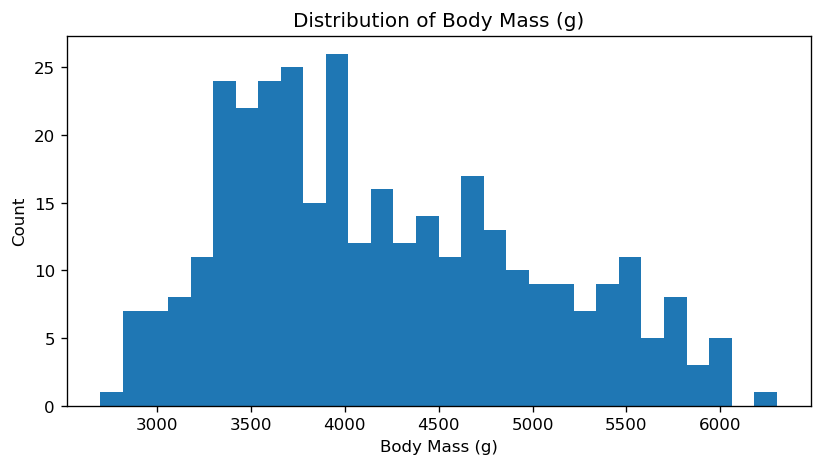

Mean: 4201.75
Median: 4050.0


In [11]:
# Distribution (histogram)
plt.figure()
plt.hist(mass, bins=30)
plt.title("Distribution of Body Mass (g)")
plt.xlabel("Body Mass (g)")
plt.ylabel("Count")
plt.show()

# Quick skew check: compare mean vs median
print("Mean:", round(mass.mean(), 2))
print("Median:", round(mass.median(), 2))

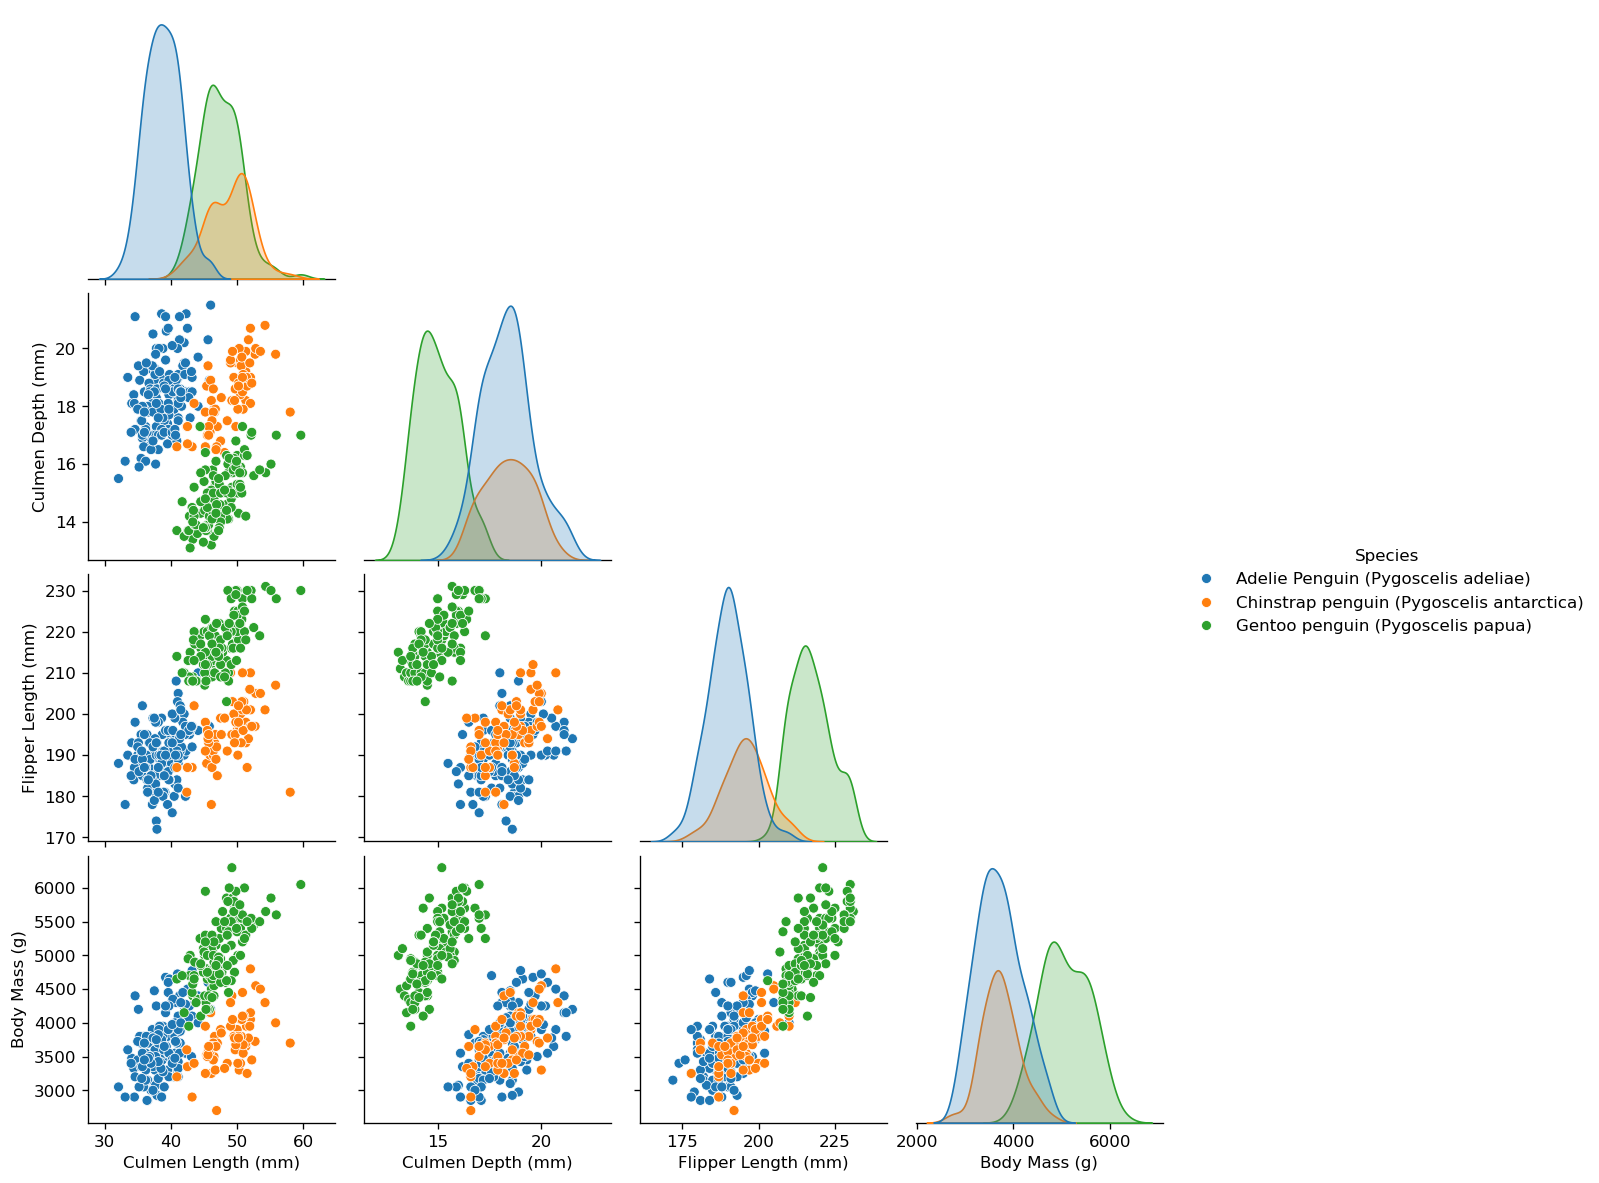

In [12]:
import seaborn as sns

pen_g = df[['Species','Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)' ]]
sns.pairplot(pen_g,
            diag_kind = 'kde',
             hue='Species',
            corner = True,
            )
plt.show()

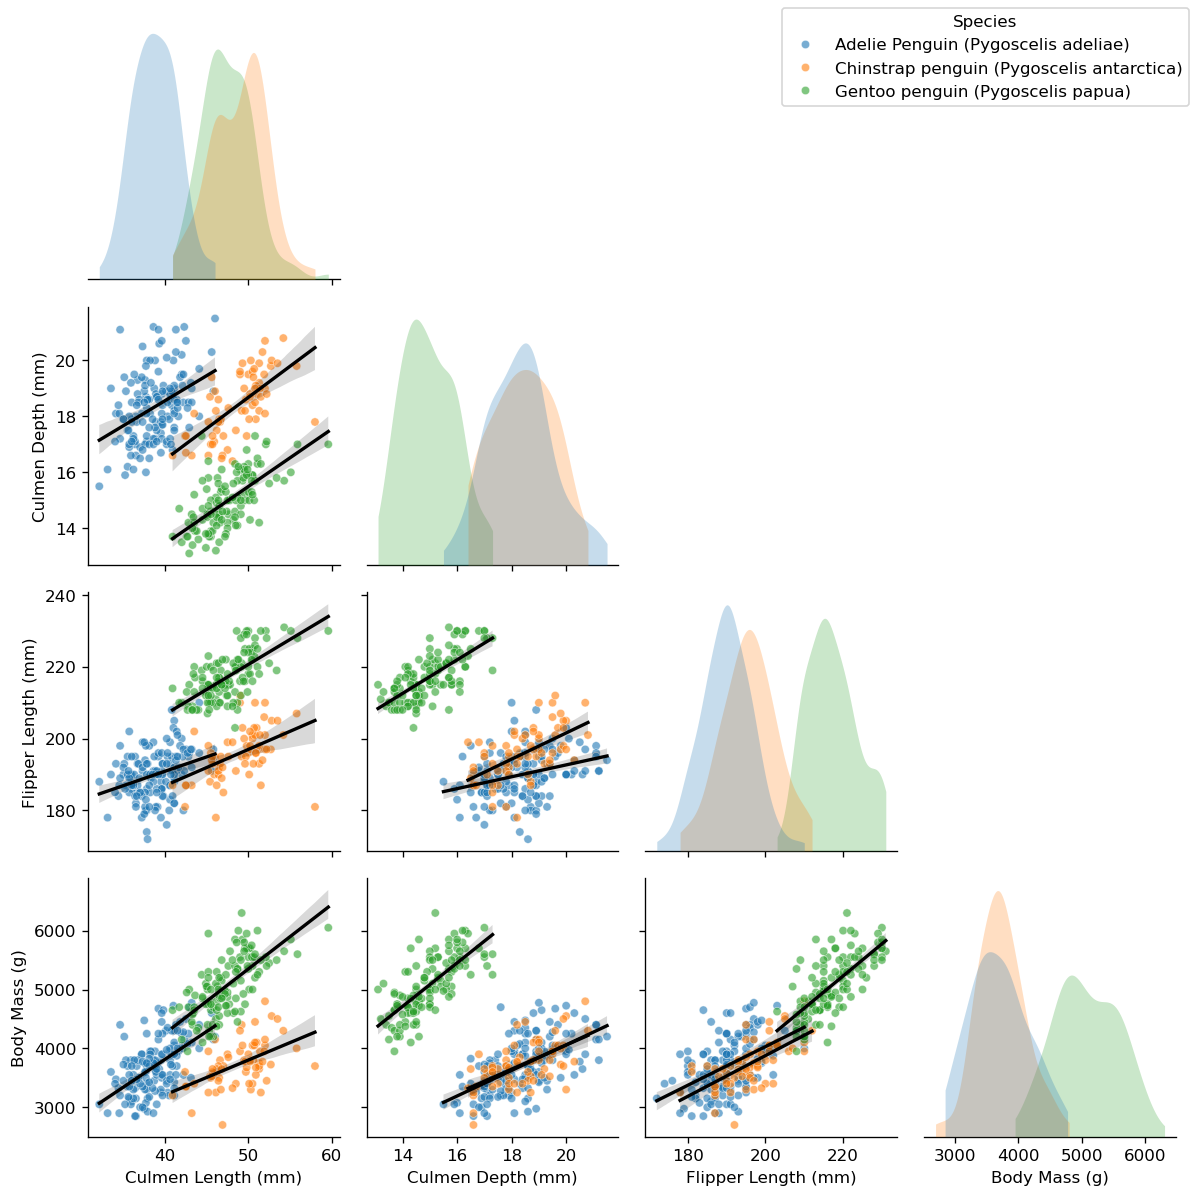

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
 
pen_g = df[['Species', 'Culmen Length (mm)', 'Culmen Depth (mm)',             'Flipper Length (mm)', 'Body Mass (g)']].dropna()
 
g = sns.PairGrid(pen_g, hue='Species', corner=True, diag_sharey=False)
# Diagonal: filled KDEs without outline
g.map_diag(sns.kdeplot, fill=True, linewidth=0, common_norm=False, cut=0)
# Lower triangle: scatter plots with hue
g.map_lower(sns.scatterplot, alpha=0.6, s=25)
# Prepare species order and line styles (to avoid total overlap ambiguity)
species_order = pen_g['Species'].dropna().unique().tolist()
# cycle through styles so black lines are distinguishable
styles = itertools.cycle(['-', '-', '-','-'])

for i, y_var in enumerate(g.y_vars):
    for j, x_var in enumerate(g.x_vars):
        if i <= j:
            continue
        ax = g.axes[i, j]
        # reset style cycle per subplot
        styles = itertools.cycle(['-', '-', '-', '-'])
        for sp in species_order:
            sub = pen_g[pen_g['Species'] == sp]
            if sub[[x_var, y_var]].dropna().shape[0] < 2:
                continue
            sns.regplot(
                data=sub, x=x_var, y=y_var, ax=ax,
                scatter=False, ci=95,      # ci=None to remove band
                color='black',
                line_kws={'lw': 2, 'ls': next(styles)}
            )
 
# Legend (from scatter colors only)
scatter_ax = next(
    (g.axes[ii, jj] for ii in range(1, g.axes.shape[0])
     for jj in range(min(ii, g.axes.shape[1])) if g.axes[ii, jj] is not None),
    g.axes.flat[0]
)
handles, labels = scatter_ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
g.fig.legend(uniq.values(), uniq.keys(), title="Species", loc="upper right")
plt.tight_layout()
plt.show()
 

In [14]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Latitude',
       'Longitude', 'Island', 'Stage', 'Individual ID', 'Clutch Completion',
       'Date Egg', 'Culmen Length (mm)', 'Culmen Depth (mm)',
       'Flipper Length (mm)', 'Body Mass (g)', 'Sex', 'Delta 15 N (o/oo)',
       'Delta 13 C (o/oo)', 'Comments'],
      dtype='object')

In [15]:
df[['Species','Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)' ]]

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,Adelie Penguin (Pygoscelis adeliae),39.1,18.7,181.0,3750.0
1,Adelie Penguin (Pygoscelis adeliae),39.5,17.4,186.0,3800.0
2,Adelie Penguin (Pygoscelis adeliae),40.3,18.0,195.0,3250.0
3,Adelie Penguin (Pygoscelis adeliae),NaN,NaN,NaN,NaN
4,Adelie Penguin (Pygoscelis adeliae),36.7,19.3,193.0,3450.0
...,...,...,...,...,...
339,Gentoo penguin (Pygoscelis papua),NaN,NaN,NaN,NaN
340,Gentoo penguin (Pygoscelis papua),46.8,14.3,215.0,4850.0
341,Gentoo penguin (Pygoscelis papua),50.4,15.7,222.0,5750.0
342,Gentoo penguin (Pygoscelis papua),45.2,14.8,212.0,5200.0


## 1.2 Understanding correlations vs. causation
We’ll compute a correlation between two numeric variables (we’ll use <strong>Flipper Length</strong> and <strong>Body Mass</strong>),
then discuss why correlation does <em>not</em> prove causation.

Using columns: Flipper Length (mm) and Body Mass (g)
Pearson correlation r = 0.871


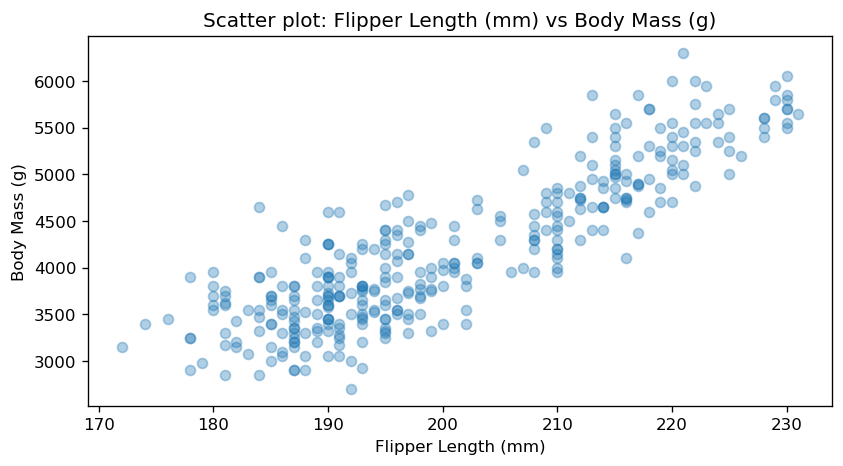

In [16]:
# Correlation demo: Flipper Length vs Body Mass
col_x = COL_FLIPPER
col_y = COL_BODY_MASS

if col_x is None or col_y is None:
    numeric_cols = df_demo.select_dtypes(include="number").columns.tolist()
    if len(numeric_cols) >= 2:
        col_x, col_y = numeric_cols[0], numeric_cols[1]
    else:
        col_x, col_y = None, None

print("Using columns:", col_x, "and", col_y)

if col_x is None or col_y is None:
    print("Not enough numeric columns available to demonstrate correlation.")
else:
    tmp = df_demo[[col_x, col_y, "species_simple"]].dropna()
    r = tmp[col_x].corr(tmp[col_y])
    print(f"Pearson correlation r = {r:.3f}")

    plt.figure()
    plt.scatter(tmp[col_x], tmp[col_y], alpha=0.35)
    plt.title(f"Scatter plot: {col_x} vs {col_y}")
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.show()

Strong positive linear relationship between flipper length and body mass (r = 0.87).

Penguins with longer flippers tend to be heavier.

However, this may be partly explained by species as a confounder — different species have both different average flipper lengths and different average body masses.

So this is association, not causation.

###Let's take a look at the confounder! 🧐

Using columns: Flipper Length (mm) and Body Mass (g)
Pearson correlation r = 0.871


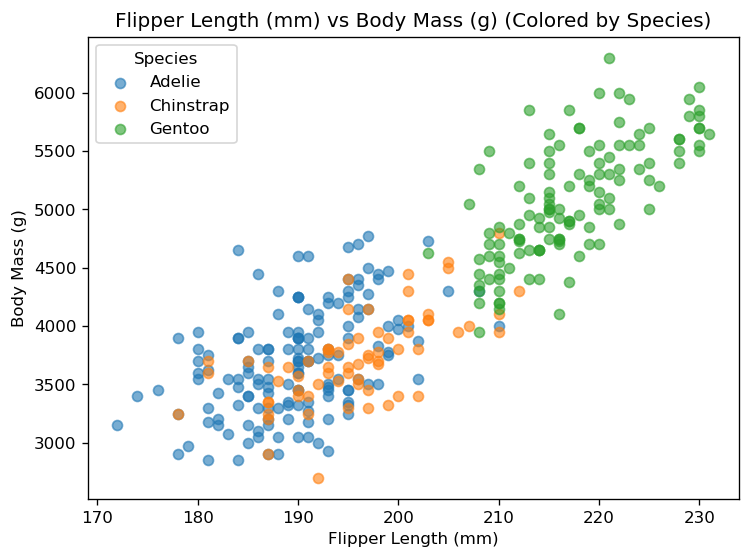

In [17]:
# Correlation demo: Flipper Length vs Body Mass (colored by species)

col_x = COL_FLIPPER
col_y = COL_BODY_MASS

if col_x is None or col_y is None:
    numeric_cols = df_demo.select_dtypes(include="number").columns.tolist()
    if len(numeric_cols) >= 2:
        col_x, col_y = numeric_cols[0], numeric_cols[1]
    else:
        col_x, col_y = None, None

print("Using columns:", col_x, "and", col_y)

if col_x is None or col_y is None:
    print("Not enough numeric columns available to demonstrate correlation.")
else:
    tmp = df_demo[[col_x, col_y, "species_simple"]].dropna()
    r = tmp[col_x].corr(tmp[col_y])
    print(f"Pearson correlation r = {r:.3f}")

    plt.figure(figsize=(7,5))

    # Plot each species in a different color
    for species in tmp["species_simple"].unique():
        subset = tmp[tmp["species_simple"] == species]
        plt.scatter(
            subset[col_x],
            subset[col_y],
            alpha=0.6,
            label=species
        )

    plt.title(f"{col_x} vs {col_y} (Colored by Species)")
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.legend(title="Species")
    plt.show()

Flipper length and body mass show a strong positive correlation overall, but this relationship is largely driven by species differences.
Species acts as a confounder: Gentoo penguins tend to have both longer flippers and higher body mass, while Adelie and Chinstrap cluster lower on both.
Within species, the relationship appears weaker, suggesting flipper length and body mass are correlated but not necessarily causally related.

## 1.3 Statistical significance and hypothesis testing basics

**Workflow:**
1. Define **H₀ (null hypothesis)** and **H₁ (alternative)**  
2. Choose a test based on data types  
3. Compute a test statistic + p-value  
4. Interpret the result in plain English

In the next section (1.4), we’ll run common tests (t-test, chi-square, ANOVA).

## 1.4 Common tests for different data types (t-tests, chi-square, ANOVA)

We’ll demonstrate:
- **t-test**: numeric outcome, 2 groups  
- **chi-square**: categorical × categorical  
- **ANOVA**: numeric outcome, 3+ groups

> If a required column doesn’t exist in your dataset, you can change the column choices below.

In [18]:
# For the hypothesis tests below, we'll mostly use:
# - Numeric outcome: Body Mass (g)
# - Groups: species_simple (3 species) and/or Island
df_demo[["species_simple", COL_ISLAND, COL_BODY_MASS]].dropna().head()

,species_simple,Island,Body Mass (g)
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
4,Adelie,Torgersen,3450.0
5,Adelie,Torgersen,3650.0


### 1.4.1 t-test (numeric outcome, 2 groups)

Example question: <strong>Is there a statistically significant difference in mean body mass between male and female Adelie penguins?</strong>

In [19]:
adelie = df_demo[df_demo["species_simple"] == "Adelie"]

g1 = adelie[adelie["Sex"] == "MALE"][COL_BODY_MASS].dropna()
g2 = adelie[adelie["Sex"] == "FEMALE"][COL_BODY_MASS].dropna()
g1_small = g1.sample(50, random_state=42)
g2_small = g2.sample(50, random_state=42)

# Welch's t-test (doesn't assume equal variances)
t_stat, p_val = stats.ttest_ind(g1_small, g2_small, equal_var=False)

print(f"Group sizes: {len(g1_small)} vs {len(g2_small)}")
print(f"t = {t_stat:.3f}, p = {p_val:.20f}")

Group sizes: 50 vs 50
t = 10.367, p = 0.00000000000000003160


Note that ... ✏️

The t-value measures how far apart the group averages are relative to the variation in the data. It’s a standardized difference. The bigger the absolute t-value, the more clearly separated the groups are.

**⭐ But for decisions, we usually look at the p-value.**

###Fact Check 🧐

In [20]:
# Filter Adelie only (same as before)
adelie = df_demo[df_demo["species_simple"] == "Adelie"].dropna(subset=[COL_BODY_MASS])

# Top 10 heaviest Adelie males
top_10_males = (
    adelie[adelie["Sex"] == "MALE"]
    .sort_values(by=COL_BODY_MASS, ascending=False)
    [["species_simple", "Sex", COL_BODY_MASS]]
    .head(10)
)

# Top 10 heaviest Adelie females
top_10_females = (
    adelie[adelie["Sex"] == "FEMALE"]
    .sort_values(by=COL_BODY_MASS, ascending=False)
    [["species_simple", "Sex", COL_BODY_MASS]]
    .head(10)
)

print("Top 10 Heaviest Adelie Males:")
print(top_10_males)

print("\nTop 10 Heaviest Adelie Females:")
print(top_10_females)

Top 10 Heaviest Adelie Males:
    species_simple   Sex  Body Mass (g)
109         Adelie  MALE         4775.0
101         Adelie  MALE         4725.0
81          Adelie  MALE         4700.0
7           Adelie  MALE         4675.0
39          Adelie  MALE         4650.0
45          Adelie  MALE         4600.0
111         Adelie  MALE         4600.0
17          Adelie  MALE         4500.0
133         Adelie  MALE         4475.0
69          Adelie  MALE         4450.0

Top 10 Heaviest Adelie Females:
    species_simple     Sex  Body Mass (g)
114         Adelie  FEMALE         3900.0
110         Adelie  FEMALE         3825.0
1           Adelie  FEMALE         3800.0
82          Adelie  FEMALE         3800.0
22          Adelie  FEMALE         3800.0
25          Adelie  FEMALE         3800.0
106         Adelie  FEMALE         3750.0
100         Adelie  FEMALE         3725.0
74          Adelie  FEMALE         3700.0
96          Adelie  FEMALE         3700.0


### 1.4.2 Chi-square (categorical × categorical)

Example question: <strong>Is penguin species associated with island?</strong>

In [21]:
assert COL_ISLAND is not None, "Island column not found. Set COL_ISLAND manually."

ct = pd.crosstab(df_demo["species_simple"], df_demo[COL_ISLAND])
ct

Island,Biscoe,Dream,Torgersen
species_simple,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


In [22]:
# Chi-square test of independence
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"chi2 = {chi2:.3f}, dof = {dof}, p = {p:.100f}")

expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
expected_df.round(1)

chi2 = 299.550, dof = 4, p = 0.0000000000000000000000000000000000000000000000000000000000000013545738297192517384386345069345270461


Island,Biscoe,Dream,Torgersen
species_simple,,,
Adelie,74.2,54.8,23.0
Chinstrap,33.2,24.5,10.3
Gentoo,60.6,44.7,18.7


dof: Degrees of freedom
represent the number of independent categories or observations that are free to vary when estimating parameters"

\
Chi-square statistic (χ² = 299.55)
A value this large means the observed distribution is dramatically different from what independence would predict.

### 1.4.3 ANOVA (numeric outcome, 3+ groups)

Example question: <strong>Does average body mass differ across species (Adelie vs Chinstrap vs Gentoo)?</strong>

In [23]:
group_col = "species_simple"

tmp = df_demo[[COL_BODY_MASS, group_col]].dropna()

# Use up to the 3 largest groups (this dataset has 3 main species)
top_groups = tmp[group_col].value_counts().head(3).index.tolist()
print("Groups used:", top_groups)

groups = [tmp.loc[tmp[group_col] == g, COL_BODY_MASS].values for g in top_groups]

f_stat, p_val = stats.f_oneway(*groups)
print(f"F = {f_stat:.3f}, p = {p_val:.100f}")

Groups used: ['Adelie', 'Gentoo', 'Chinstrap']
F = 343.626, p = 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000002892368133377200730


Note that ... ✏️

ANOVA uses an F-statistic, which is just a ratio of between-group variance to within-group variance.
If F is much larger than 1, then it suggests that group means differ more than random noise would suggest.

In [24]:
# if ANOVA is significant, run Tukey HSD (post-hoc) to see which pairs differ
tmp2 = tmp[tmp[group_col].isin(top_groups)].copy()
if tmp2.shape[0] > 0:
    tukey = pairwise_tukeyhsd(endog=tmp2[COL_BODY_MASS], groups=tmp2[group_col], alpha=0.05)
    print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


1️⃣ Adelie vs Chinstrap

There is no significant difference in mean body mass between Adelie and Chinstrap penguins.

The confidence interval includes 0 → difference could realistically be zero.

2️⃣ Adelie vs Gentoo

Gentoo penguins have a significantly higher mean body mass than Adelie.
The difference is large (~1375g), and the CI does not include 0.

3️⃣ Chinstrap vs Gentoo

Gentoo penguins also have a significantly higher mean body mass than Chinstrap.

🎯 Overall Conclusion

- Gentoo is **significantly heavier** than both Adelie and Chinstrap

- Adelie and Chinstrap are **not significantly different** from each other

So the ANOVA result is explained by the fact that:

➡️ The difference is driven by Gentoo vs the other two species.

---


# **Half-time break! 🎉**
(half-way reward: https://tinyurl.com/yutk5n9w 🐧)
---

---
# Part 2 — Machine Learning Demo

---

## 2.2 Classification vs. regression (and when clustering fits)

Before you pick an algorithm, you must pick the **problem type**:

- **Classification (supervised)**: predict a **category** (label).  
  Here: predict `species_simple` (Adelie / Chinstrap / Gentoo).

- **Regression (supervised)**: predict a **number** (continuous value).  
  Here: predict `Body Mass (g)`.

- **Clustering (unsupervised)**: you **don’t have labels**; group similar rows.  
  Here: group penguins by measurements and inspect whether “natural groups” appear.

Below, we’ll set up **two targets** (one for classification, one for regression) and a **feature set** we can reuse.

In [25]:
# data preparation and exploratory setup

# 1) Define a reusable list of candidate predictor column names.

#    Include both numeric measurements (useful for regression) and categorical attributes (useful for classification or encoding).
candidate_features = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
    "Delta 15 N (o/oo)",
    "Delta 13 C (o/oo)",
    "Island",
    "Sex",
    "Clutch Completion",
]

# 2) Filter the candidate list to only include columns that actually exist in 'df'.

#    This prevents KeyError when selecting columns and makes the code robust to
#    variations in CSV files (columns added/removed).
#    Result: 'features' is the final ordered list of columns we will use as inputs.
features = [c for c in candidate_features if c in df.columns]
print("Using features:", features)

# 3) Build the feature matrix X from the dataframe using the validated column list.

#    Use .copy() to avoid SettingWithCopyWarning and to ensure X is an independent
#    object for downstream preprocessing, transformations, or model input.
X = df_demo[features].copy()

# 4) Define targets for two separate problems:

#    - y_class: the discrete label used for multiclass classification (species).
#    - y_reg  : the continuous target used for regression (body mass in grams).
#    Keep these as separate Series so each modeling pipeline can consume the
#    appropriate target without interference.
y_class = df_demo["species_simple"]            # classification target (multiclass)
y_reg   = df_demo["Body Mass (g)"]             # regression target (continuous)

# 5) Display class counts to inspect label distribution and detect imbalance.

#    Knowing class counts helps decide whether to apply class weighting,
#    resampling, or stratified splits later.
display(
    pd.DataFrame({
        "y_class (species_simple)": y_class.value_counts(dropna=False)
    }).rename_axis("label")
)

# 6) Print a concise summary of the regression target to understand scale and spread.

#    Use describe() to see count, mean, std, min/max and quartiles; this informs
#    whether scaling, log-transform, or outlier handling is needed.
print("\nRegression target summary (Body Mass g):")
display(y_reg.describe())

Using features: ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Island', 'Sex', 'Clutch Completion']


,y_class (species_simple)
label,
Adelie,152
Gentoo,124
Chinstrap,68



Regression target summary (Body Mass g):


count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: Body Mass (g), dtype: float64

**What are we observing?**

✅ This is a multiclass classification problem (3 species).

✅ Classes are not perfectly balanced (Chinstrap is smaller).

✅ Body mass is continuous → good regression target.

## 2.3 Common algorithms for tabular data

We’ll compare:
- **Logistic Regression** (baseline, interpretable)
- **Linear Regression**
- **Decision Tree**
- **Random Forest**
- **K-means (optional, exploratory)**

### 2.3.1 Logistic regression

We are now going to test a Logistic Regression classification model to predict penguin species (Adelie, Chinstrap, Gentoo)

based on their physical measurements and categorical features (culmen length, flipper length, island, sex, etc.).

We then evaluate performance on a held-out test set using accuracy, precision, recall, F1-score, and a confusion matrix.

\
We’ll use **scikit-learn** with a reusable preprocessing pipeline:

- **Numeric columns**: impute missing values with the median + scale (optional but helpful)
- **Categorical columns**: impute missing values with the most frequent + one-hot encode

Then we’ll plug in different models in later sections.

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        38
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      1.00      1.00        31

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



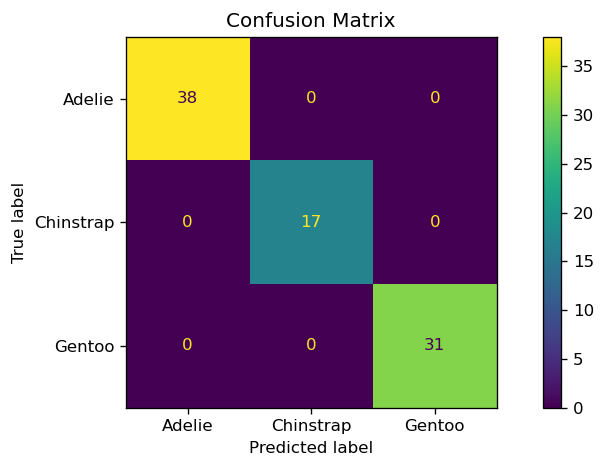

In [26]:
# Question: Can we accurately predict penguin species (Adelie, Chinstrap, Gentoo) using the selected features?

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Detect which columns are numeric vs categorical so we can preprocess them differently ---

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

# --- Numeric preprocessing pipeline ---

# 1) SimpleImputer(strategy="median") fills missing numeric values with the column median,
#    which is robust to outliers and preserves the central tendency.
# 2) StandardScaler standardizes features to mean=0, std=1 so models converge faster and
#    features are on comparable scales (important for many algorithms).
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# --- Categorical preprocessing pipeline ---

# 1) SimpleImputer(strategy="most_frequent") fills missing category values with the most common value.
#    This is simple and keeps categories intact rather than dropping rows.
# 2) OneHotEncoder converts categorical values into binary indicator columns (one per category).
#    handle_unknown="ignore" avoids errors if a rare category appears in test data that wasn't in training.
#    sparse_output=False returns a dense array so it composes cleanly with ColumnTransformer pipelines.
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# --- Combine numeric and categorical pipelines into a single preprocessor ---

# ColumnTransformer applies the correct pipeline to each column subset and drops any remaining columns.
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# --- Full model pipeline ---

# The pipeline first applies preprocessing, then fits a LogisticRegression classifier on the transformed features.
# Using a pipeline ensures the exact same preprocessing is applied at train and test time.
clf = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

# --- Train / test split ---

# We stratify the split on y_class so the training and test sets keep the same class proportions.
# This helps produce a representative test set and more stable evaluation for imbalanced classes.

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class,
    test_size=0.25,        # 25% of data reserved for testing
    random_state=42,       # fixed seed for reproducibility
    stratify=y_class       # preserve class distribution between train and test
)

# --- Fit the pipeline to training data ---

# This runs: imputation -> scaling/encoding -> fit logistic regression on transformed features.
clf.fit(X_train, y_train)

# --- Generate predictions on the held-out test set ---
y_pred = clf.predict(X_test)

# --- Evaluation: accuracy and detailed classification metrics ---

# Accuracy: proportion of correct predictions overall.

# classification_report: precision/recall/f1 per class which give deeper insight than accuracy alone.
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- Confusion matrix visualization ---

# The confusion matrix shows counts of true vs predicted labels; diagonal = correct predictions.

labels = sorted(y_class.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Accuracy = 1.0 → 100% of the 86 test penguins were classified correctly.

Precision = 1.00 → When the model predicted a species, it was always correct.

Recall = 1.00 → The model found every true instance of each species (no misses).

F1-score = 1.00 → Perfect balance between precision and recall.

Support = 38 Adelie, 17 Chinstrap, 31 Gentoo → Number of test samples per species.

Confusion matrix → All values are on the diagonal (38, 17, 31) and zeros elsewhere, meaning no misclassifications.

So the answer to

*Can we accurately predict penguin species (Adelie, Chinstrap, Gentoo) using the selected features?*

is: Yes ✅ The logistic regression model achieved 100% accuracy on the test set with no misclassifications.



>**❗Important note**:
>
>100% accuracy is rare in real-world problems (but believable here because species measurements are clearly separable). It often means:
>
>🚩 Data leakage
>
>🚩 The test set is too small
>
>🚩 The problem is too easy
>
>🚩 Overfitting

\
➡️ What happened?

We trained a Logistic Regression model on 256 penguins to learn how measurements relate to species.

Now we can input a penguin’s measurements, and the model will predict whether it is Adelie, Chinstrap, or Gentoo.

### 2.3.2 Linear Regression

We’ll do **regression**: predict **Body Mass (g)** using a **Linear Regression** model.

What we’ll do:
1) filter rows that have a known body mass
2) split into train/test
3) fit a linear regression pipeline
4) evaluate with an intuitive metric (**R²**) and a quick error summary (**MAE**)

In [27]:
# Question: Can we predict a penguin’s body mass using its physical measurements (like flipper length, culmen size, etc.)?

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression

# --- Remove rows where the regression target (Body Mass) is missing ---

# For regression, we cannot train on rows where the target value is NaN.
# mask_reg is True only for rows where body mass exists.
mask_reg = y_reg.notna()

# Apply the mask to both features (X) and target (y_reg)
# This ensures X and y stay aligned after filtering.
X_reg = X.loc[mask_reg]
y_reg_clean = y_reg.loc[mask_reg]

# --- Train / test split ---

# 25% of the data is reserved for testing.
# random_state ensures the split is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg_clean,
    test_size=0.25,
    random_state=42
)

# --- Build regression pipeline ---

# Reuse the same preprocessing pipeline (imputation + scaling + encoding).
# LinearRegression fits a straight-line relationship between features and body mass.
linreg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

# --- Train the model ---

# The pipeline first preprocesses the data, then fits the linear regression model.
linreg.fit(X_train, y_train)

# --- Make predictions on unseen test data ---
pred = linreg.predict(X_test)

# --- Evaluate model performance ---

# R^2 measures how much variance in body mass is explained by the model (range: 0 to 1).
# MAE (Mean Absolute Error) measures the average prediction error in grams.
print("Linear Regression — Body Mass (g)")
print("R^2:", r2_score(y_test, pred))
print("MAE (g):", mean_absolute_error(y_test, pred))

Linear Regression — Body Mass (g)
R^2: 0.9052950008076672
MAE (g): 202.3377077955828


Here, R² = 0.91, which means the model explains about 91% of the differences in body mass across penguins — this is a strong result.

MAE ≈ 202 g means that, on average, the model’s predictions are off by about 202 grams, which is relatively small compared to typical body masses (~4000 g).

\
🧐 When we say the model “explains 91% of the variation,” what do we mean?

we mean:

Penguins have different body masses. Some are heavier, some are lighter.
There is natural variation in body mass across the dataset.

R² tells us how much of those differences the model can account for using the features (flipper length, culmen size, etc.).

So:

If R² = 0 → the model explains none of the differences. It’s basically guessing.

If R² = 1 → the model perfectly captures all differences.

If R² = 0.91 → the model accounts for 91% of why penguins differ in body mass.

(The remaining 9% is unexplained — due to noise, missing variables, or randomness.)

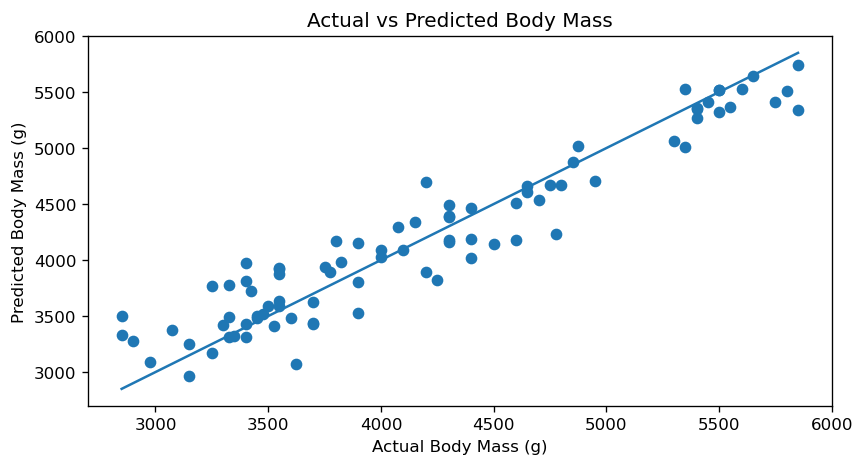

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(y_test, pred)

# Perfect prediction line
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Body Mass (g)")
plt.ylabel("Predicted Body Mass (g)")
plt.title("Actual vs Predicted Body Mass")
plt.show()

This plot shows actual body mass on the x-axis and predicted body mass on the y-axis. The diagonal line represents perfect predictions — if the model were 100% accurate, every point would lie exactly on that line.
\
Each blue dot is a penguin from the test set. The closer the dots are to the diagonal line, the better our model is performing, which visually explains why our R² is high.

\
So the answer to the question:
> Can we predict a penguin’s body mass using its physical measurements (like flipper length, culmen size, etc.)?

is: Yes ✅ quite well. The model explains about 91% of the differences in body mass (R² = 0.91) and is off by about 202 grams on average (MAE ≈ 202 g).

\
➡️ What happened?

* We trained a linear regression model on 256 penguins.

* Now we can feed it measurements of a new penguin, and it will output a predicted body mass.

### 2.3.3 Decision Trees

Decision Trees work like a flowchart: they split the data into smaller and smaller groups.

We’ll train a **Decision Tree Classifier** for species prediction and compare metrics.

In [29]:
!pip install graphviz

In [30]:
# Question: Can we predict a penguin’s species (Adelie, Chinstrap, Gentoo) using its physical measurements and categorical features? (decision tree version)

# --- correct classification training (use species label, not body mass) ---
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
import graphviz # Import graphviz

# make sure y_class exists and is the target for classification
# split with stratify to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class,
    test_size=0.25,        # 25% of data reserved for testing
    random_state=42,       # fixed seed for reproducibility
    stratify=y_class       # preserve class distribution between train and test
)

# build tree pipeline (reuse preprocess)
tree_cls = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=4))
])

tree_cls.fit(X_train, y_train)
pred_tree = tree_cls.predict(X_test)

print("Decision Tree (max_depth=4) — Species")
print("Accuracy:", round(accuracy_score(y_test, pred_tree), 3))
print("\nClassification Report:")
print(classification_report(y_test, pred_tree, zero_division=0))

# *** visualization of learned decision rules inside the trained Decision Tree model. ***

# --- Extract the trained decision tree model from the pipeline ---
#
# Since we used a Pipeline, the actual tree is inside the "model" step.
model = tree_cls.named_steps["model"]

# Get feature names after preprocessing (important because one-hot encoding expands features)
feature_names = tree_cls.named_steps["preprocess"].get_feature_names_out()

# --- Export the tree structure to Graphviz format ---

# export_graphviz converts the trained tree into a visual representation.
# filled=True colors nodes by class purity.
# rounded=True makes the nodes visually cleaner.
dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=feature_names,
    class_names=model.classes_.astype(str),
    filled=True,
    rounded=True,
    special_characters=True
)

# --- Render the decision tree visualization ---

# This displays the tree as a flowchart-like diagram.
graph = graphviz.Source(dot_data)
graph

Decision Tree (max_depth=4) — Species
Accuracy: 0.965

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        38
   Chinstrap       1.00      0.88      0.94        17
      Gentoo       0.94      1.00      0.97        31

    accuracy                           0.97        86
   macro avg       0.97      0.95      0.96        86
weighted avg       0.97      0.97      0.96        86



ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

Performance:

* Accuracy ≈ 0.97 → The tree correctly classified about 97% of test penguins.

* F1 (macro) ≈ 0.96 → Strong performance across all three species, balanced across classes.

* Slightly lower than logistic regression (which was 100%), but still very strong.

What the tree learned

* The first and most important split is Flipper Length → this is the strongest separator of species.
   > So the first decision the tree learned is: **Is Flipper Length ≤ 0.406?**

* Then it uses features like Delta 13 C, Culmen Length, Island, and Culmen Depth.

* Many terminal nodes have *gini = 0, meaning those leaves are perfectly pure (only one species).
>(* Gini Index or Gini impurity measures the degree or probability of a particular variable being wrongly classified when it is randomly chosen. )

What this tells us

* Species are highly separable using physical measurements.

* Flipper length is the most powerful predictor.

* A relatively shallow tree (max_depth=4) is enough to classify almost perfectly.


\
So the answer to the question:
> Can we predict a penguin’s species (Adelie, Chinstrap, Gentoo) using its physical measurements and categorical features, using a decision tree model? (decision tree version)

is: Yes ✅ the Decision Tree learned clear splitting rules (like flipper length and island) and achieved about 97% accuracy on unseen penguins.

\
➡️ What happened?

* We trained a Decision Tree classifier on 256 penguins to learn rules that separate species based on their measurements.

* Now the model can follow those learned decision rules to predict the species of a new penguin.

A decision tree keeps splitting until it:

* Reaches the maximum depth,

* The node becomes pure (all samples belong to one class), or

* No split improves the impurity measure (e.g., Gini or entropy).

## 2.5 Decision Tree Feature Importance

Tree-based models can report **feature importance** (how much each feature helped reduce impurity).

We extract feature importances from the trained Decision Tree model using its built-in impurity-based importance metric.

(Note: Because we use one-hot encoding, a single categorical feature becomes multiple columns.)

Top features by importance:


,feature,importance
0,num__Flipper Length (mm),0.524026
1,num__Delta 13 C (o/oo),0.326625
2,num__Culmen Length (mm),0.066910
3,cat__Island_Dream,0.060375
4,num__Culmen Depth (mm),0.011683
5,num__Delta 15 N (o/oo),0.010380
6,cat__Island_Biscoe,0.000000
7,cat__Island_Torgersen,0.000000
8,cat__Sex_.,0.000000
9,cat__Sex_FEMALE,0.000000


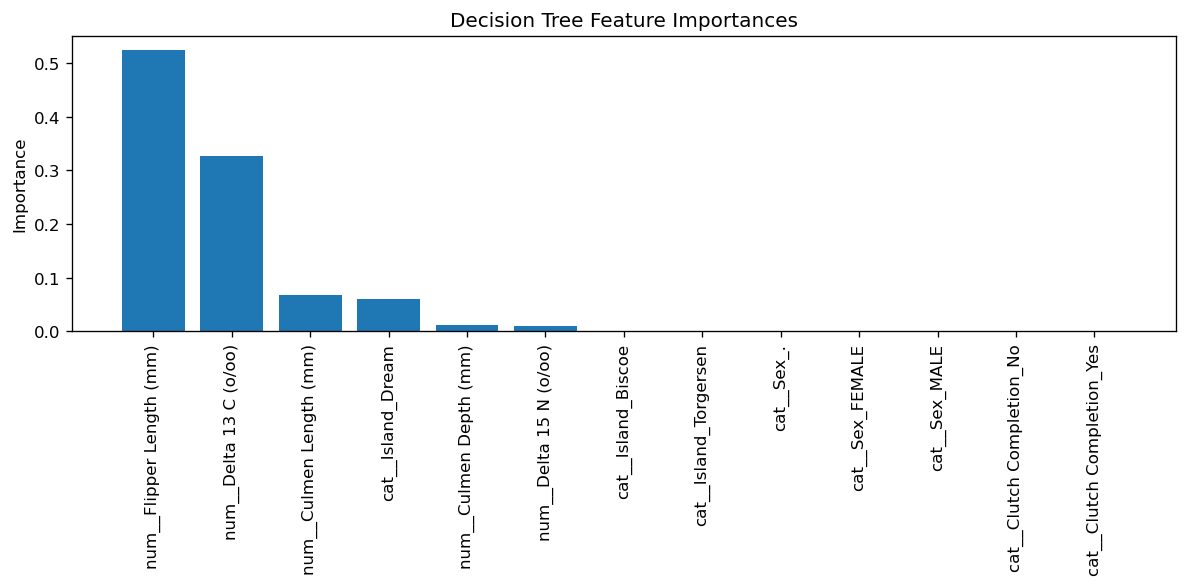

In [31]:
# Feature importance after a trained Decision Tree pipeline (assumes `tree_cls` exists)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Safety checks ---
if "tree_cls" not in globals():
    raise RuntimeError("Could not find `tree_cls`. Run the cell that trains the decision tree pipeline first.")

# --- Extract the trained tree model from the pipeline ---
# If your pipeline variable is named differently, replace `tree_cls` with that name.
model = tree_cls.named_steps.get("model", None)
if model is None:
    # fallback: if pipeline steps are ordered differently
    model = tree_cls.steps[-1][1]

# --- Try to get feature names AFTER preprocessing (handles one-hot expansion) ---
feature_names = None
try:
    preproc = tree_cls.named_steps.get("preprocess", None)
    if preproc is not None:
        # get_feature_names_out works for ColumnTransformer on recent sklearn versions
        feature_names = preproc.get_feature_names_out()
except Exception:
    feature_names = None

# Final fallback: try to use the original X columns (may not reflect one-hot expansion)
if feature_names is None:
    if "X" in globals():
        feature_names = np.array(X.columns.tolist())
    else:
        # last resort: use numeric placeholders
        feature_names = np.array([f"f{i}" for i in range(len(model.feature_importances_))])

# --- Get importance values ---
importances = model.feature_importances_

# --- Build a DataFrame and sort by importance ---
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Display top features as a table
print("Top features by importance:")
display(fi.head(10))

# Plot the importances (sorted)
plt.figure(figsize=(10, 5))
plt.bar(fi["feature"], fi["importance"])
plt.xticks(rotation=90)
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

Flipper Length is the most important feature (~52%), meaning it drives most of the species separation.

Delta 13 C is the second strongest predictor (~33%), with Culmen Length and Island (Dream) contributing much less.

All other features, including Sex and Clutch Completion, have near-zero importance, meaning the tree barely used them to classify species.




---


**From:** 🐧

**To:** the curious minds wondering what the second variable is!

> Delta 13 C represents the stable carbon isotope ratio in my blood tissue. It's like a tiny chemical diary of where I’ve been eating. The food I eat leaves a carbon signature in my blood, so scientists can tell where I’ve been eating my sushi rolls! 🍱
---


## 2.6 Avoiding Overfitting (Real-World Caveats)

We’ll make overfitting visible by training decision trees with increasing depth and comparing:

- **Training accuracy** (how well the model fits the data it has already seen)
- **Test accuracy** (how well the model performs on unseen data)

If training accuracy keeps improving but test accuracy gets worse, that’s **overfitting**.


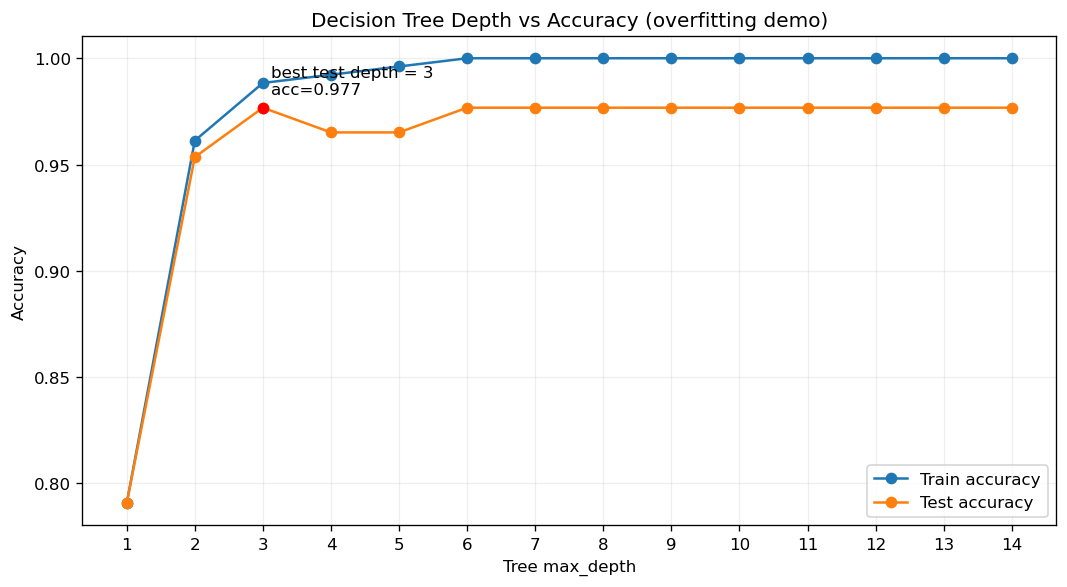

Max training accuracy: 1.000 at depth 6
Max test accuracy:     0.977 at depth 3


In [32]:
# Overfitting demo: Decision Tree depth vs train/test accuracy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- Safety: require X and y_class to exist ---
if "X" not in globals() or "y_class" not in globals():
    raise RuntimeError("Please run the cells that define X (features) and y_class (target) before this cell.")

# --- If a preprocessing object doesn't exist, build a minimal one ---
if "preprocess" not in globals():
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]
    numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    from sklearn.pipeline import Pipeline as SKPipeline
    preprocess = ColumnTransformer([("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)], remainder="drop")

# --- Train/test split (stratified so class proportions are preserved) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, # Use y_class here
    test_size=0.25,
    random_state=42,
    stratify=y_class # And here
)

# --- Sweep over tree depths and collect accuracies ---
depths = list(range(1, 15))            # try depths 1..15
train_scores = []
test_scores = []

for d in depths:
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_pred = pipe.predict(X_train)
    test_pred  = pipe.predict(X_test)
    train_scores.append(accuracy_score(y_train, train_pred))
    test_scores.append(accuracy_score(y_test, test_pred))

# --- Plot results ---
plt.figure(figsize=(9,5))
plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, test_scores, marker="o", label="Test accuracy")
plt.xlabel("Tree max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy (overfitting demo)")
plt.xticks(depths)
plt.grid(alpha=0.2)
plt.legend()

# Annotate best test depth
best_idx = int(np.argmax(test_scores))
plt.scatter([depths[best_idx]], [test_scores[best_idx]], color="red", zorder=5)
plt.annotate(f"best test depth = {depths[best_idx]}\nacc={test_scores[best_idx]:.3f}",
             (depths[best_idx], test_scores[best_idx]),
             textcoords="offset points", xytext=(5,8))

plt.tight_layout()
plt.show()

# --- Quick numeric summary printed below the plot ---
print(f"Max training accuracy: {max(train_scores):.3f} at depth {depths[int(np.argmax(train_scores))]}")
print(f"Max test accuracy:     {max(test_scores):.3f} at depth {depths[best_idx]}")

At small depths (1–2), both training and test accuracy are lower → the model is underfitting.

At depth 3, test accuracy peaks (~0.98) → this is the best balance between bias and variance.

As depth increases further, training accuracy reaches 1.0 while test accuracy stops improving → the tree is starting to overfit by memorizing the training data instead of improving generalization.

>⭐ **Key takeaway**
>* If train accuracy keeps rising while test accuracy peaks then falls, the model is overfitting at deeper depths.

### **(Full decision tree, if we ignored overfitting 👀)**

In [33]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz


print(f"\nDecision Tree (max_depth={6})")

tree = Pipeline([
      ("preprocess", preprocess),
      ("model", DecisionTreeClassifier(max_depth=6, random_state=42))
])

tree.fit(X_train, y_train)

# Extract trained tree
model = tree.named_steps["model"]
feature_names = tree.named_steps["preprocess"].get_feature_names_out()

dot_data = export_graphviz(
     model,
     out_file=None,
     feature_names=feature_names,
     class_names=model.classes_.astype(str),
     filled=True,
     rounded=True
)

graph = graphviz.Source(dot_data)
display(graph)


Decision Tree (max_depth=6)


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH